# MAU ref global (Python)

Notebook version of `mau_ref_global.py`: Prophet total MAU with `DperMar` regressor.

**Setup:** use a kernel where `pandas`, `prophet`, `matplotlib`, and `openpyxl` are installed (e.g. `pip install -r requirements-prophet.txt`).

Edit **paths and filenames** in the config cell to match your Box inputs.

In [ ]:
# Optional: install deps into the active kernel
%pip install -q pandas prophet matplotlib openpyxl

In [2]:
%matplotlib inline

import calendar
import os
from datetime import date, timedelta

import matplotlib.pyplot as plt
import pandas as pd
from prophet import Prophet

## Config — edit these

In [3]:
D_ACT_START = date(2022, 1, 1)
D_ACT_END = date(2026, 1, 31)
D_FSTART = D_ACT_END + timedelta(days=1)
D_FEND = D_FSTART + timedelta(days=364 * 3)
D_TODAY = date.today().strftime("%Y.%m.%d")

IN_DIR = os.path.expanduser(
    "/Users/grac/Library/CloudStorage/Box-Box/Internal Reporting (CPL)/FP&A/"
    "Modelling/03. MAU/07. Prophet Model/02. Prophet Inputs/"
)
OUT_DIR = os.path.expanduser(
    "/Users/grac/Library/CloudStorage/Box-Box/Internal Reporting (CPL)/FP&A/"
    "Modelling/03. MAU/07. Prophet Model/03. Prophet Outputs/"
)

METRIC = "MAU"  # or "Signups"
COL = "TOTAL_SIGNUPS" if METRIC == "Signups" else "TOTAL_MAU"
FILE_MAIN = "2026.02.16 Signups.csv" if METRIC == "Signups" else "2026.02.20 MAU.csv"


def days_in_month(dt: pd.Timestamp) -> int:
    return calendar.monthrange(dt.year, dt.month)[1]

## Load inputs

In [4]:
os.makedirs(OUT_DIR, exist_ok=True)

path_main = os.path.join(IN_DIR, FILE_MAIN)
path_ms_a = os.path.join(IN_DIR, "2026.02.16 Looker_MS_A_D.csv")
path_ms_f = os.path.join(IN_DIR, "2026.02.16 MS_F_M.csv")
path_hol = os.path.join(IN_DIR, "2026.01.05 collated_holidays.csv")

df = pd.read_csv(path_main)
ms_a_d = pd.read_csv(path_ms_a)
ms_f_m = pd.read_csv(path_ms_f)
hol_raw = pd.read_csv(path_hol)

df.shape, ms_a_d.shape, ms_f_m.shape, hol_raw.shape

/var/folders/_r/02xbgjj12k98ptx4kqsbq9yh0000gn/T/ipykernel_12589/1047279178.py:8: DtypeWarning: Columns (0: DATE, 1: EOMONTH) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path_main)


((297200, 3), (21663, 3), (492, 4), (4377, 4))

## Actuals and regressor table `R`

In [5]:
a = (
    df.assign(ds=pd.to_datetime(df["DATE"], format="%m/%d/%Y").dt.normalize())
    .loc[lambda x: (x["ds"].dt.date >= D_ACT_START) & (x["ds"].dt.date <= D_ACT_END)]
    .groupby("ds", as_index=False)[COL]
    .sum(min_count=1)
    .rename(columns={COL: "y"})
)
full_act = pd.DataFrame({"ds": pd.date_range(D_ACT_START, D_ACT_END, freq="D")})
a = full_act.merge(a, on="ds", how="left")
a["y"] = a["y"].fillna(0)

ds_ms_a_d = (
    ms_a_d.assign(ds=pd.to_datetime(ms_a_d["ds"], format="%m/%d/%Y").dt.normalize())
    .loc[lambda x: x["ds"].dt.date <= D_ACT_END]
    .groupby("ds", as_index=False)["perMar"]
    .sum(min_count=1)
    .rename(columns={"perMar": "DperMar"})
)

ms_f_m2 = ms_f_m.copy()
ms_f_m2["MONTH"] = pd.to_datetime(ms_f_m2["MONTH"], format="%m/%d/%Y")
ds_ms_f_m = (
    ms_f_m2.loc[ms_f_m2["BUDGET"] == "Performance Marketing"]
    .assign(m=lambda x: x["MONTH"].dt.to_period("M").dt.to_timestamp())
    .groupby("m", as_index=False)["TARGET"]
    .sum(min_count=1)
    .rename(columns={"TARGET": "pm"})
)

t_full = pd.DataFrame({"ds": pd.date_range(D_ACT_START, D_FEND, freq="D")})
t_fstart = pd.DataFrame({"ds": pd.date_range(D_FSTART, D_FEND, freq="D")})
t_fstart["m"] = t_fstart["ds"].dt.to_period("M").dt.to_timestamp()
forecast_daily = t_fstart.merge(ds_ms_f_m, on="m", how="left")
forecast_daily["DperMar"] = (
    forecast_daily["pm"].fillna(0)
    / forecast_daily["m"].map(lambda d: days_in_month(pd.Timestamp(d)))
)
forecast_daily = forecast_daily[["ds", "DperMar"]]

r = t_full.merge(ds_ms_a_d, on="ds", how="left")
r = r.merge(forecast_daily, on="ds", how="left", suffixes=("", "_y"))
r["DperMar"] = r["DperMar"].combine_first(r["DperMar_y"]).fillna(0)
r = r[["ds", "DperMar"]]

train = (
    r.merge(a, on="ds", how="left")
    .loc[lambda x: x["ds"].dt.date <= D_ACT_END][["ds", "y", "DperMar"]]
    .assign(
        ds=lambda x: pd.to_datetime(x["ds"]),
        y=lambda x: pd.to_numeric(x["y"], errors="coerce"),
        DperMar=lambda x: pd.to_numeric(
            x["DperMar"].astype(str).str.replace(",", "", regex=False),
            errors="coerce",
        ),
    )
    .dropna(subset=["ds"])
    .sort_values("ds")
    .reset_index(drop=True)
)
train.tail()

,ds,y,DperMar
1487,2026-01-27,233307901.0,270167.928676
1488,2026-01-28,234750072.0,260189.076226
1489,2026-01-29,236288093.0,270309.479880
1490,2026-01-30,237803500.0,263861.561789
1491,2026-01-31,239308998.0,251838.246633


## Fit Prophet and forecast

In [6]:
us_hol = hol_raw.loc[hol_raw["country"] == "US"].copy()
holidays_df = us_hol.assign(
    ds=pd.to_datetime(us_hol["ds"], format="%m/%d/%Y")
)[["holiday", "ds"]].reset_index(drop=True)

prophet_kw = dict(
    changepoint_range=0.7,
    daily_seasonality=False,
    weekly_seasonality=4,
    yearly_seasonality=10,
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10,
)
if not holidays_df.empty:
    prophet_kw["holidays"] = holidays_df

m = Prophet(**prophet_kw)
m.add_regressor("DperMar", standardize=False)
m.fit(train)

fc = m.predict(r)
f = fc[["ds", "yhat"]].rename(columns={"yhat": "MAU"})
f["ds"] = pd.to_datetime(f["ds"]).dt.normalize()

monthly = (
    f.assign(Date=lambda x: x["ds"] + pd.offsets.MonthEnd(0))
    .groupby("Date", as_index=False)["MAU"]
    .sum()
)
f.shape, monthly.shape

15:58:41 - cmdstanpy - INFO - Chain [1] start processing
15:58:41 - cmdstanpy - INFO - Chain [1] done processing
15:58:41 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
15:58:41 - cmdstanpy - INFO - Chain [1] start processing
15:58:46 - cmdstanpy - INFO - Chain [1] done processing


((2585, 2), (85, 2))

## Excel export (optional)

In [7]:
out_xlsx = os.path.join(OUT_DIR, f"{D_TODAY}_Outputs_Total_Prophet_DperMar.xlsx")
with pd.ExcelWriter(out_xlsx, engine="openpyxl") as writer:
    f.to_excel(writer, sheet_name="Total_Daily", index=False)
    monthly.to_excel(writer, sheet_name="Total_Monthly", index=False)
print(out_xlsx)

/Users/grac/Library/CloudStorage/Box-Box/Internal Reporting (CPL)/FP&A/Modelling/03. MAU/07. Prophet Model/03. Prophet Outputs/2026.03.26_Outputs_Total_Prophet_DperMar.xlsx


## Charts

Run the cells below after fitting the model. Figures appear inline under each cell.

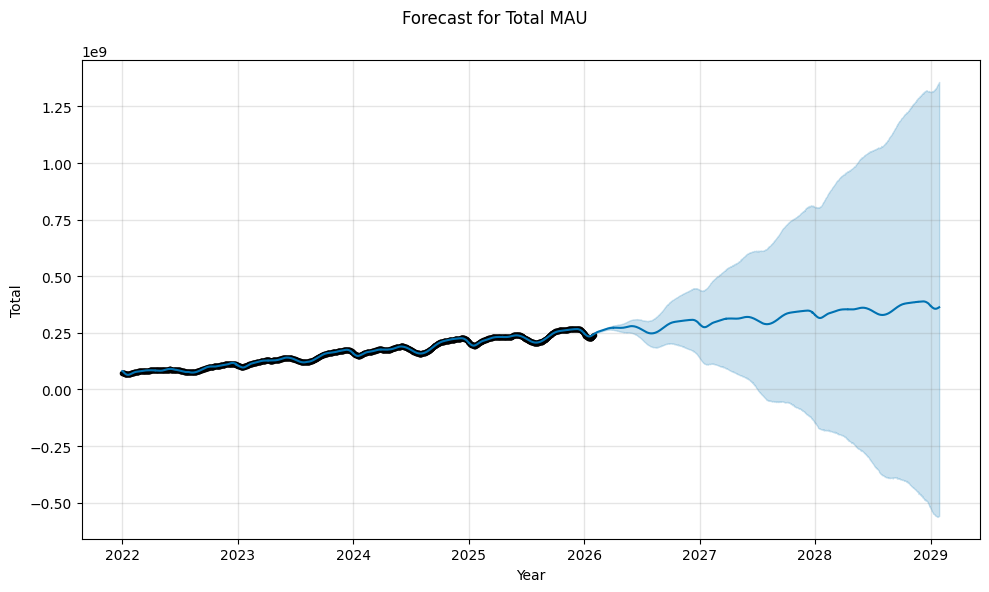

In [8]:
fig1 = m.plot(fc)
fig1.suptitle(f"Forecast for Total {METRIC}")
fig1.axes[0].set_xlabel("Year")
fig1.axes[0].set_ylabel("Total")
fig1.tight_layout()

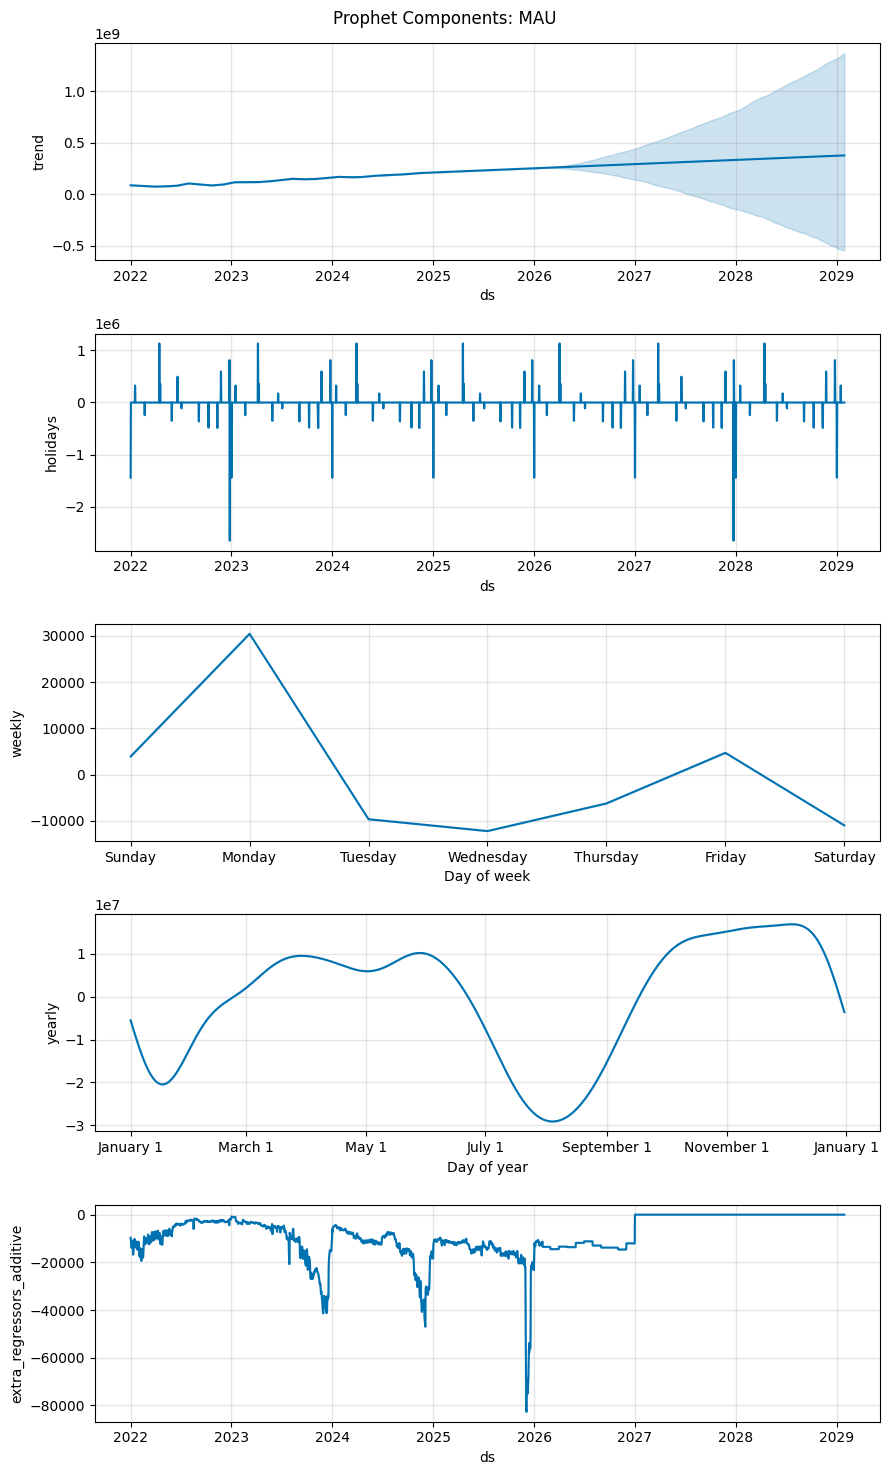

In [9]:
fig2 = m.plot_components(fc)
fig2.suptitle(f"Prophet Components: {METRIC}")
fig2.tight_layout()